
# GluA2 turnover summary (rounds 12 & 13 & 14)

This notebook loads `/nearline/spruston/Boaz/DELTA/GluA2_round_12 / 3  / 4.parquet`  inspects columns, and summarizes mean turnover per animal and per brain region. Turnover is assumed to be stored in the `fraction` column.


In [ ]:

from pathlib import Path
import pandas as pd
import numpy as np


In [2]:

round_paths = {
    12: Path('/nearline/spruston/Boaz/DELTA/GluA2_round_12.parquet'),
    13: Path('/nearline/spruston/Boaz/DELTA/GluA2_round_13.parquet'),
    14: Path('/nearline/spruston/Boaz/DELTA/GluA2_round_14.parquet'),
}
round_paths


{12: PosixPath('/nearline/spruston/Boaz/DELTA/GluA2_round_12.parquet'),
 13: PosixPath('/nearline/spruston/Boaz/DELTA/GluA2_round_13.parquet'),
 14: PosixPath('/nearline/spruston/Boaz/DELTA/GluA2_round_14.parquet')}

In [3]:

# Load both parquet files
frames = []
for rnd, path in round_paths.items():
    df = pd.read_parquet(path)
    df = df.assign(round_id=rnd)
    frames.append(df)
combined = pd.concat(frames, ignore_index=True)
combined.shape


(19528, 31)

In [4]:



# Load Allen CCF structure tree from local CSV
# Exclude anything whose structure_id_path includes fiber tracts (1009), ventricular systems (73), or grooves (1024)
tree_csv = Path('../structure_tree_safe_2017.csv')
ccf_df = pd.read_csv(tree_csv, usecols=['id', 'structure_id_path'])
ccf_df['structure_id_path'] = ccf_df['structure_id_path'].astype(str)
path = ccf_df['structure_id_path']
exclude_ids = set(
    ccf_df.loc[
        path.str.contains(r'(?:^|/)1009(?:/|$)')
        | path.str.contains(r'(?:^|/)73(?:/|$)')
        | path.str.contains(r'(?:^|/)1024(?:/|$)'),
        'id'
    ].astype(int)
)

cid = pd.to_numeric(combined['CCF_ID'], errors='coerce')
mask_keep = (combined['valid'] == 1) & cid.notna() & (~cid.astype(int).isin(exclude_ids))
combined_filtered = combined.loc[mask_keep].copy()
combined_filtered.shape


(16004, 31)

In [5]:

# Map fine regions (Name) to coarse categories (new_names) for coloring
name_to_newname = (
    combined_filtered[['Name', 'new_names']]
    .dropna(subset=['Name'])
    .drop_duplicates('Name')
    .set_index('Name')['new_names']
    .to_dict()
)


In [6]:

# Inspect available columns and a small sample
combined_filtered.columns.tolist()


['ANM',
 'Sex',
 'groupName',
 'AP',
 'Slice',
 'Name',
 'CCF_ID',
 'tau',
 'tau_values',
 'fp',
 'P_Mean',
 'P_STD',
 'N',
 'C_Mean',
 'C_STD',
 'File',
 'fraction',
 'sum_sd',
 'Age',
 'Line',
 'SizeX',
 'Centroid',
 'SizeY',
 'Hemi',
 'Round',
 'bbox',
 'AP2',
 'new_names',
 'valid',
 'layer',
 'round_id']

In [7]:

combined_filtered.head()


,ANM,Sex,groupName,AP,Slice,Name,CCF_ID,tau,tau_values,fp,...,Centroid,SizeY,Hemi,Round,bbox,AP2,new_names,valid,layer,round_id
1,BM32,male,reversal,509.798756,1.0,Olfactory areas,698.0,4.458668,"[3.4912722, 3.6663854, 3.5032556, 3.3866372, 3...","[0.31799674, 0.33588287, 0.31924546, 0.3069370...",...,"[446.0293176972281, 761.4182012017833]",1113.0,both,12.0,"[212.5, 950.5, 8.0, 12.0]",11.0,Olfactory areas,1.0,0.0,12
2,BM32,male,reversal,509.798756,1.0,Main olfactory bulb,507.0,3.636976,"[3.532244, 3.3679717, 3.5429032, 3.245798, 3.4...","[0.322251, 0.30493447, 0.32335076, 0.29160285,...",...,"[609.8551899780239, 792.8676351749128]",1113.0,both,12.0,"[212.5, 950.5, 8.0, 12.0]",11.0,Olfactory areas,1.0,0.0,12
6,BM32,male,reversal,490.772650,2.0,Main olfactory bulb,507.0,3.562126,"[3.3741841, 3.5530202, 3.4313145, 3.6897347, 3...","[0.30560195, 0.32439193, 0.3116938, 0.33820984...",...,"[602.3719617310882, 755.2311399244535]",1113.0,both,12.0,"[152.5, 786.5, 785.0, 501.0]",10.0,Olfactory areas,1.0,0.0,12
9,BM32,male,reversal,477.887663,3.0,"Accessory olfactory bulb, granular layer",196.0,3.672558,"[3.3218927, 3.2988155, 3.3579557, 2.9688253, 3...","[0.299952, 0.2974359, 0.3038561, 0.25993225, 0...",...,"[788.4967127857914, 780.6199587871652]",1114.0,both,12.0,"[144.5, 790.5, 830.0, 493.0]",10.0,Olfactory areas,1.0,0.0,12
10,BM32,male,reversal,477.887663,3.0,Olfactory areas,698.0,4.299175,"[3.260567, 3.0664275, 3.1334062, 3.2957761, 2....","[0.29323512, 0.27132183, 0.2789937, 0.29710352...",...,"[587.1834992887624, 700.3202347083926]",1114.0,both,12.0,"[144.5, 790.5, 830.0, 493.0]",10.0,Olfactory areas,1.0,0.0,12


In [15]:

# Unique animals present
animals = combined_filtered['ANM'].unique()
animals


array(['BM32', 'BM33', 'BM34', 'BM37', 'BM35', 'BM38', 'BM36', 'BM39',
       'BM40'], dtype=object)

In [16]:
def weighted_mean_col(df, value_col: str):
    w = df['N'].to_numpy()
    v = df[value_col].to_numpy()
    mask = np.isfinite(w) & np.isfinite(v) & (w > 0)
    if mask.sum() == 0:
        return np.nan
    return float(np.average(v[mask], weights=w[mask]))

def weighted_mean_fraction(df):
    return weighted_mean_col(df, 'fraction')

def weighted_mean_tau(df):
    return weighted_mean_col(df, 'tau')


In [17]:

# Mean turnover (fraction) per animal across all regions/slices (weighted by N)
mean_fraction_per_animal = (
    combined_filtered.groupby('ANM')
    .apply(weighted_mean_fraction)
    .reset_index(name='mean_fraction_all_regions_weighted')
)
mean_fraction_per_animal


,ANM,mean_fraction_all_regions_weighted
0,BM32,0.381661
1,BM33,0.511117
2,BM34,0.519566
3,BM35,0.498223
4,BM36,0.481000
5,BM37,0.508777
6,BM38,0.542826
7,BM39,0.590877
8,BM40,0.563587


In [18]:

# Mean turnover per animal per brain region (using "Name" as region label, weighted by N)
mean_fraction_per_animal_region = (
    combined_filtered.groupby(['ANM', 'Name'])
    .apply(weighted_mean_fraction)
    .reset_index(name='mean_fraction_region_weighted')
    .sort_values(['ANM', 'Name'])
)
mean_fraction_per_animal_region.head(20)


,ANM,Name,mean_fraction_region_weighted
0,BM32,Abducens nucleus,0.407445
1,BM32,Accessory facial motor nucleus,0.429289
2,BM32,"Accessory olfactory bulb, glomerular layer",0.428692
3,BM32,"Accessory olfactory bulb, granular layer",0.335775
4,BM32,"Accessory olfactory bulb, mitral layer",0.336638
5,BM32,Accessory supraoptic group,0.422769
6,BM32,"Agranular insular area, dorsal part, layer 1",0.313260
7,BM32,"Agranular insular area, dorsal part, layer 2/3",0.283726
8,BM32,"Agranular insular area, dorsal part, layer 5",0.295765
9,BM32,"Agranular insular area, dorsal part, layer 6a",0.347104


In [19]:

# Overall mean turnover per region across all animals (weighted by N)
mean_fraction_per_region = (
    combined_filtered.groupby('Name')
    .apply(weighted_mean_fraction)
    .reset_index(name='mean_fraction_all_animals_weighted')
    .sort_values('mean_fraction_all_animals_weighted', ascending=False)
)
mean_fraction_per_region.head(20)


,Name,mean_fraction_all_animals_weighted
144,"Frontal pole, layer 1",0.664716
145,"Frontal pole, layer 2/3",0.648540
29,"Anterior cingulate area, dorsal part, layer 1",0.643704
476,"Secondary motor area, layer 1",0.640475
422,"Primary somatosensory area, trunk, layer 1",0.636881
404,"Primary somatosensory area, lower limb, layer 1",0.635918
434,"Primary somatosensory area, upper limb, layer 1",0.634680
393,"Primary motor area, Layer 1",0.634064
380,"Prelimbic area, layer 1",0.629241
290,"Orbital area, lateral part, layer 1",0.626314


In [20]:

# Quick stats to ensure loading is correct
summary_stats = combined['fraction'].describe()
summary_stats


count    19290.000000
mean         0.513143
std          0.082408
min          0.197148
25%          0.456032
50%          0.512645
75%          0.569690
max          0.813532
Name: fraction, dtype: float64

In [21]:

# Load behavioral learning summary CSV
behavior_csv = Path('/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/dprime_learning_summary.csv')
behavior = pd.read_csv(behavior_csv)
behavior.head()


,animal,rev_start,dates_used,num_trials,num_windows,slope,intercept,mean_accuracy,mean_dprime,time_to_criterion_trial,within_day_gain_1,within_day_gain_2,within_day_gain_3,within_day_gain_sum,figure
0,BM32,2025-06-28,"2025-06-28, 2025-06-29, 2025-06-30",1226,1197,0.001890,0.019690,0.662316,1.118724,606.0,2.862240,3.226200,2.957438,9.045877,/groups/spruston/home/moharb/DELTA_Behavior/ou...
1,BM33,2025-08-03,"2025-08-03, 2025-08-04, 2025-08-05",1032,1003,0.001714,-0.739395,0.547481,0.326817,886.0,2.710051,2.557884,3.210957,8.478892,/groups/spruston/home/moharb/DELTA_Behavior/ou...
2,BM35,2025-09-24,"2025-09-24, 2025-09-25, 2025-09-26",1171,1142,0.002345,-0.213941,0.671221,1.144012,501.0,2.340500,3.130637,3.267327,8.738465,/groups/spruston/home/moharb/DELTA_Behavior/ou...
3,BM36,2025-09-24,"2025-09-24, 2025-09-25, 2025-09-26",1881,1852,0.001934,-1.434306,0.594896,0.659529,1209.0,2.483455,3.475941,3.889966,9.849362,/groups/spruston/home/moharb/DELTA_Behavior/ou...
4,BM37,2025-10-11,"2025-10-11, 2025-10-12, 2025-10-13",1140,1111,0.002629,-1.423463,0.524561,0.181751,1045.0,3.165560,2.103993,3.707844,8.977398,/groups/spruston/home/moharb/DELTA_Behavior/ou...


In [22]:

# Restrict to animals present in turnover data
behavior = behavior.rename(columns={'animal': 'ANM'})
available_animals = set(combined_filtered['ANM'].unique())
behavior = behavior[behavior['ANM'].isin(available_animals)].copy()
behavior.head()


,ANM,rev_start,dates_used,num_trials,num_windows,slope,intercept,mean_accuracy,mean_dprime,time_to_criterion_trial,within_day_gain_1,within_day_gain_2,within_day_gain_3,within_day_gain_sum,figure
0,BM32,2025-06-28,"2025-06-28, 2025-06-29, 2025-06-30",1226,1197,0.001890,0.019690,0.662316,1.118724,606.0,2.862240,3.226200,2.957438,9.045877,/groups/spruston/home/moharb/DELTA_Behavior/ou...
1,BM33,2025-08-03,"2025-08-03, 2025-08-04, 2025-08-05",1032,1003,0.001714,-0.739395,0.547481,0.326817,886.0,2.710051,2.557884,3.210957,8.478892,/groups/spruston/home/moharb/DELTA_Behavior/ou...
2,BM35,2025-09-24,"2025-09-24, 2025-09-25, 2025-09-26",1171,1142,0.002345,-0.213941,0.671221,1.144012,501.0,2.340500,3.130637,3.267327,8.738465,/groups/spruston/home/moharb/DELTA_Behavior/ou...
3,BM36,2025-09-24,"2025-09-24, 2025-09-25, 2025-09-26",1881,1852,0.001934,-1.434306,0.594896,0.659529,1209.0,2.483455,3.475941,3.889966,9.849362,/groups/spruston/home/moharb/DELTA_Behavior/ou...
4,BM37,2025-10-11,"2025-10-11, 2025-10-12, 2025-10-13",1140,1111,0.002629,-1.423463,0.524561,0.181751,1045.0,3.165560,2.103993,3.707844,8.977398,/groups/spruston/home/moharb/DELTA_Behavior/ou...


In [23]:

from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

metrics = [
    'slope',
    'intercept',
    'mean_accuracy',
    'mean_dprime',
    'time_to_criterion_trial',
    'within_day_gain_sum',
]

VOLCANO_DIR = Path('/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning')
VOLCANO_DIR.mkdir(parents=True, exist_ok=True)

def compute_weighted_turnover(region_col: str, value_col: str = 'fraction', residual: bool = False):
    df = combined_filtered.copy()
    measure_label = value_col + ('_resid' if residual else '')
    if residual:
        df = df.copy()
        df['__value__'] = df[value_col] - df.groupby('ANM')[value_col].transform('mean')
        val_col = '__value__'
    else:
        val_col = value_col

    def wmean(sub):
        return weighted_mean_col(sub, val_col)

    animal_turnover = (
        df.groupby('ANM')
        .apply(wmean)
        .reset_index(name=f'{measure_label}_mean_all_regions_weighted')
    )
    region_turnover = (
        df.groupby(['ANM', region_col])
        .apply(wmean)
        .reset_index(name=f'{measure_label}_mean_region_weighted')
        .rename(columns={region_col: 'region'})
    )
    return animal_turnover, region_turnover, measure_label

def correlate_and_volcano(region_col: str, value_col: str = 'fraction', residual: bool = False):
    animal_turnover, region_turnover, measure_label = compute_weighted_turnover(region_col, value_col, residual)
    # Region size proxy: sum of N per region
    size_series = combined_filtered.groupby(region_col)['N'].sum()
    size_map = size_series.to_dict()

    results = []
    for metric in metrics:
        merged = behavior[['ANM', metric]].dropna()
        for region, sub in region_turnover.groupby('region'):
            tmp = sub.merge(merged, on='ANM')
            if len(tmp) < 3:
                continue
            val_col = f'{measure_label}_mean_region_weighted'
            lr = linregress(tmp[val_col], tmp[metric])
            results.append({
                'metric': metric,
                'region': region,
                'n': len(tmp),
                'slope': lr.slope,
                'intercept': lr.intercept,
                'r_value': lr.rvalue,
                'p_value': lr.pvalue,
                'region_col': region_col,
                'value_col': value_col,
                'residual': residual,
                'measure_label': measure_label,
                'region_N_sum': size_map.get(region, np.nan),
            })
        tmp = animal_turnover.merge(merged, on='ANM').dropna()
        if len(tmp) >= 3:
            val_col_global = f'{measure_label}_mean_all_regions_weighted'
            lr = linregress(tmp[val_col_global], tmp[metric])
            results.append({
                'metric': metric,
                'region': 'ALL_REGIONS_MEAN',
                'n': len(tmp),
                'slope': lr.slope,
                'intercept': lr.intercept,
                'r_value': lr.rvalue,
                'p_value': lr.pvalue,
                'region_col': region_col,
                'value_col': value_col,
                'residual': residual,
                'measure_label': measure_label,
                'region_N_sum': np.nan,
            })
    corr_df = pd.DataFrame(results)
    if corr_df.empty:
        return corr_df
    corr_df['p_value'] = corr_df['p_value'].clip(lower=np.finfo(float).tiny)
    corr_df['neg_log10_p'] = -np.log10(corr_df['p_value'])

    if region_col == 'Name':
        corr_df['coarse'] = corr_df['region'].map(name_to_newname)
    else:
        corr_df['coarse'] = corr_df['region']

    for metric in metrics:
        dfm = corr_df[corr_df['metric'] == metric]
        if dfm.empty:
            continue
        plt.figure(figsize=(8, 6))
        if region_col == 'Name':
            hue_col = 'coarse'
            legend = 'brief'
        else:
            hue_col = 'region'
            legend = 'brief'
        sns.scatterplot(data=dfm, x='slope', y='neg_log10_p', hue=hue_col, legend=legend)
        if region_col == 'Name':
            for _, row in dfm.iterrows():
                plt.text(row['slope'], row['neg_log10_p'], str(row['region']), fontsize=6)
        plt.axvline(0, color='gray', linestyle='--', linewidth=1)
        plt.xlabel(f'Slope of weighted {measure_label} vs {metric}')
        plt.ylabel('-log10(p-value)')
        plt.title(f'Volcano: {metric} (region_col={region_col}, measure={measure_label})')
        plt.tight_layout()
        out_path = VOLCANO_DIR / f'volcano_{region_col}_{measure_label}_{metric}.png'
        plt.savefig(out_path, dpi=200)
        plt.close()
    return corr_df


In [24]:

# Run correlations and volcano plots for different region columns and measures
corr_fraction_new_names = correlate_and_volcano('new_names', value_col='fraction', residual=True)
corr_fraction_layer = correlate_and_volcano('layer', value_col='fraction', residual=True)
corr_fraction_name = correlate_and_volcano('Name', value_col='fraction', residual=True)

# Tau residual (remove per-animal mean before weighting)
corr_tau_resid_name = correlate_and_volcano('Name', value_col='fraction', residual=True)

corr_tau_resid_name.head()


,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse
0,slope,Abducens nucleus,7,0.000044,0.002447,0.003539,0.993992,Name,fraction,True,fraction_resid,39690.0,0.002617,Medulla
1,slope,Accessory facial motor nucleus,7,0.001972,0.002497,0.159721,0.732294,Name,fraction,True,fraction_resid,9657.0,0.135314,Medulla
2,slope,"Accessory olfactory bulb, glomerular layer",8,-0.006607,0.002677,-0.467026,0.243325,Name,fraction,True,fraction_resid,132594.0,0.613814,Olfactory areas
3,slope,"Accessory olfactory bulb, granular layer",8,-0.007533,0.001738,-0.391348,0.337701,Name,fraction,True,fraction_resid,197342.0,0.471468,Olfactory areas
4,slope,"Accessory olfactory bulb, mitral layer",8,-0.011309,0.001480,-0.462276,0.248800,Name,fraction,True,fraction_resid,347895.0,0.604149,Olfactory areas


In [26]:
# Sorted regions by slope for each metric (tau residual, Name-level), p < 0.05
for m in corr_fraction_new_names['metric'].unique():
    subset = corr_fraction_new_names[
        (corr_fraction_new_names['metric'] == m) 
    ]
    if subset.empty:
        print(f"\nMetric: {m} (no hits at p<0.05)")
        continue
    print(f"\nMetric: {m}")
    display(
        subset.sort_values('slope', ascending=False)[['region', 'slope', 'p_value', 'n']]
    )



Metric: slope


,region,slope,p_value,n
12,ALL_REGIONS_MEAN,0.016076,0.787888,8
4,Isocortex,0.009967,0.371162,8
10,Striatum,0.003866,0.783152,8
8,Pallidum,0.000060,0.994300,8
5,Medulla,-0.000891,0.879687,8
9,Pons,-0.001901,0.770372,8
2,Hippocampal formation,-0.001957,0.811695,8
11,Thalamus,-0.002496,0.725514,8
0,Cerebellum,-0.002584,0.804720,8
6,Midbrain,-0.004123,0.556179,8



Metric: intercept


,region,slope,p_value,n
25,ALL_REGIONS_MEAN,139.746524,0.202237,8
23,Striatum,34.775603,0.172775,8
20,Olfactory areas,19.697810,0.623158,8
21,Pallidum,10.034224,0.535918,8
13,Cerebellum,5.929012,0.772692,8
17,Isocortex,1.904883,0.933160,8
16,Hypothalamus,0.437004,0.973327,8
24,Thalamus,-0.399010,0.977355,8
19,Midbrain,-0.500964,0.971438,8
18,Medulla,-1.198662,0.917540,8



Metric: mean_accuracy


...

,region,slope,p_value,n
51,ALL_REGIONS_MEAN,103.696917,0.218547,8
49,Striatum,23.462540,0.239016,8
46,Olfactory areas,11.747701,0.703014,8
47,Pallidum,5.518632,0.659185,8
43,Isocortex,4.095752,0.813307,8
39,Cerebellum,1.813009,0.908409,8
50,Thalamus,-1.153448,0.914574,8
44,Medulla,-1.205217,0.891764,8
48,Pons,-1.304831,0.894378,8
45,Midbrain,-1.376865,0.897614,8



Metric: time_to_criterion_trial


,region,slope,p_value,n
53,Cortical subplate,9867.245664,0.355381,8
54,Hippocampal formation,3482.804416,0.488771,8
59,Olfactory areas,319.998967,0.980169,8
56,Isocortex,45.286568,0.994993,8
61,Pons,-233.496050,0.954381,8
58,Midbrain,-252.642919,0.954661,8
55,Hypothalamus,-392.505808,0.924646,8
57,Medulla,-533.368978,0.884623,8
63,Thalamus,-932.166156,0.834301,8
52,Cerebellum,-1908.929192,0.769650,8



Metric: within_day_gain_sum


,region,slope,p_value,n
66,Cortical subplate,11.586133,0.798149,8
67,Hippocampal formation,10.172203,0.625239,8
71,Midbrain,3.198449,0.860282,8
76,Thalamus,1.544421,0.932656,8
74,Pons,1.186306,0.943406,8
69,Isocortex,0.209227,0.994350,8
70,Medulla,-0.876506,0.953595,8
68,Hypothalamus,-2.559725,0.880180,8
73,Pallidum,-12.828388,0.543100,8
65,Cerebellum,-20.899793,0.421888,8


In [27]:
# Sorted regions by slope for each metric (tau residual, Name-level), p < 0.05
for m in corr_fraction_layer['metric'].unique():
    subset = corr_fraction_layer[
        (corr_fraction_layer['metric'] == m) 
    ]
    if subset.empty:
        print(f"\nMetric: {m} (no hits at p<0.05)")
        continue
    print(f"\nMetric: {m}")
    display(
        subset.sort_values('slope', ascending=False)[['region', 'slope', 'p_value', 'n']]
    )



Metric: slope


,region,slope,p_value,n
5,6.0,0.049113,0.345880,8
9,ALL_REGIONS_MEAN,0.016076,0.787888,8
3,4.0,0.013624,0.687207,8
4,5.0,0.013509,0.387475,8
2,2.0,0.005315,0.467744,8
1,1.0,0.004058,0.484736,8
7,8.0,0.002733,0.657841,8
6,7.0,0.000537,0.884766,8
8,9.0,-0.000903,0.908649,8
0,0.0,-0.006893,0.587330,8



Metric: intercept


,region,slope,p_value,n
15,6.0,215.531121,0.006153,8
19,ALL_REGIONS_MEAN,139.746524,0.202237,8
17,8.0,5.482092,0.651203,8
13,4.0,5.265326,0.937359,8
14,5.0,4.844322,0.878765,8
10,0.0,1.938490,0.938934,8
12,2.0,-1.043855,0.943529,8
16,7.0,-1.514014,0.835284,8
11,1.0,-2.904118,0.802994,8
18,9.0,-6.063217,0.693377,8



Metric: mean_accuracy


...

,region,slope,p_value,n
35,6.0,157.922021,0.012003,8
39,ALL_REGIONS_MEAN,103.696917,0.218547,8
34,5.0,7.272725,0.764064,8
37,8.0,6.639970,0.467795,8
32,2.0,0.830212,0.941316,8
36,7.0,-0.022697,0.996757,8
31,1.0,-0.613952,0.945202,8
30,0.0,-0.767095,0.968408,8
38,9.0,-1.863315,0.874945,8
33,4.0,-7.899145,0.877464,8



Metric: time_to_criterion_trial


,region,slope,p_value,n
48,9.0,2970.349873,0.539018,8
41,1.0,977.026003,0.791522,8
42,2.0,666.524393,0.886685,8
46,7.0,630.168070,0.784956,8
44,5.0,312.715791,0.975294,8
43,4.0,-256.669235,0.990379,8
47,8.0,-278.886857,0.942800,8
40,0.0,-997.142964,0.901218,8
49,ALL_REGIONS_MEAN,-33525.754634,0.351601,8
45,6.0,-53449.259768,0.068224,8



Metric: within_day_gain_sum


,region,slope,p_value,n
58,9.0,14.187797,0.470748,8
57,8.0,8.339953,0.595621,8
56,7.0,5.379326,0.564896,8
54,5.0,0.416875,0.991956,8
52,2.0,0.365552,0.984785,8
51,1.0,-0.098997,0.994797,8
50,0.0,-9.377742,0.774904,8
53,4.0,-19.829038,0.819603,8
59,ALL_REGIONS_MEAN,-60.323362,0.691806,8
55,6.0,-64.539884,0.638289,8


In [28]:
corr_tau_resid_name.sort_values('p_value').head(30)

,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse
128,slope,"Entorhinal area, medial part, dorsal zone, lay...",8,-0.032952,0.002948,-0.962916,0.000124,Name,fraction,True,fraction_resid,1991895.0,3.906651,Hippocampal formation
1546,mean_accuracy,"Primary motor area, Layer 6a",8,8.338113,0.741327,0.914619,0.001458,Name,fraction,True,fraction_resid,4376775.0,2.836213,Isocortex
2123,mean_dprime,"Primary motor area, Layer 6a",8,59.944275,1.707713,0.909250,0.001744,Name,fraction,True,fraction_resid,4376775.0,2.758558,Isocortex
969,intercept,"Primary motor area, Layer 6a",8,77.938218,0.503313,0.904726,0.002011,Name,fraction,True,fraction_resid,4376775.0,2.696696,Isocortex
129,slope,"Entorhinal area, medial part, dorsal zone, lay...",8,-0.021346,0.002575,-0.902329,0.002162,Name,fraction,True,fraction_resid,1337784.0,2.665129,Hippocampal formation
354,slope,"Posterior auditory area, layer 6b",8,-0.022811,0.002038,-0.890787,0.002996,Name,fraction,True,fraction_resid,24769.0,2.523506,Isocortex
533,slope,"Temporal association areas, layer 6b",8,-0.029770,0.001788,-0.886667,0.003337,Name,fraction,True,fraction_resid,128755.0,2.476661,Isocortex
335,slope,"Perirhinal area, layer 6b",8,-0.027845,0.001715,-0.885821,0.003410,Name,fraction,True,fraction_resid,23179.0,2.467249,Isocortex
89,slope,Cuneate nucleus,4,0.015910,0.003638,0.994161,0.005839,Name,fraction,True,fraction_resid,114706.0,2.233673,Medulla
374,slope,"Postrhinal area, layer 6b",8,-0.028923,0.001487,-0.856799,0.006576,Name,fraction,True,fraction_resid,51271.0,2.182069,Isocortex


In [29]:
# Sorted regions by slope for each metric (tau residual, Name-level), p < 0.05
for m in corr_tau_resid_name['metric'].unique():
    subset = corr_tau_resid_name[
        (corr_tau_resid_name['metric'] == m) &
        (corr_tau_resid_name['p_value'] < 0.05)
    ]
    if subset.empty:
        print(f"\nMetric: {m} (no hits at p<0.05)")
        continue
    print(f"\nMetric: {m}\n")
    
    display(subset.sort_values('slope', ascending=True)[['region', 'slope', 'p_value', 'n' ,'r_value', 'region_N_sum']])
                                                    




Metric: slope



,region,slope,p_value,n,r_value,region_N_sum
213,"Lateral visual area, layer 6a",-0.044489,0.038264,8,-0.733753,340582.0
452,"Retrosplenial area, dorsal part, layer 6a",-0.042328,0.030817,8,-0.753633,1098906.0
469,"Rostrolateral area, layer 5",-0.037420,0.038395,8,-0.733426,374650.0
220,"Laterointermediate area, layer 6a",-0.037392,0.036033,8,-0.739438,137309.0
546,"Ventral auditory area, layer 6a",-0.034697,0.023502,8,-0.776296,392729.0
470,"Rostrolateral area, layer 6a",-0.034436,0.026985,8,-0.765031,232729.0
387,"Primary auditory area, layer 6a",-0.033167,0.013508,8,-0.815981,423693.0
128,"Entorhinal area, medial part, dorsal zone, lay...",-0.032952,0.000124,8,-0.962916,1991895.0
385,"Primary auditory area, layer 4",-0.030959,0.013860,8,-0.814311,316349.0
101,"Dorsal auditory area, layer 6a",-0.030879,0.019564,8,-0.790359,269564.0



Metric: intercept



,region,slope,p_value,n,r_value,region_N_sum
626,"Anterolateral visual area, layer 6a",-51.902872,0.011000,7,-0.869505,132232.0
791,"Lateral visual area, layer 6b",-50.811251,0.024435,8,-0.773181,59690.0
699,"Entorhinal area, lateral part, layer 1",-48.019860,0.044779,8,-0.718220,1271656.0
931,"Posterior auditory area, layer 6b",-38.372071,0.027909,8,-0.762196,24769.0
826,Median preoptic nucleus,36.787371,0.021463,7,0.827893,21787.0
615,"Anterior cingulate area, ventral part, layer 5",48.816613,0.045111,8,0.717466,1571608.0
658,Claustrum,50.898057,0.026532,8,0.766442,762857.0
597,"Agranular insular area, ventral part, layer 6a",57.121507,0.027624,8,0.763065,252772.0
609,"Anterior cingulate area, dorsal part, layer 6a",57.244377,0.025085,8,0.771057,1040589.0
1011,"Primary somatosensory area, upper limb, layer 6a",60.741711,0.019035,8,0.792380,1520741.0



Metric: mean_accuracy



...

,region,slope,p_value,n,r_value,region_N_sum
2202,"Rostrolateral area, layer 6b",-55.191528,0.034359,8,-0.743848,44514.0
2084,"Posterior auditory area, layer 6a",-49.141680,0.042033,8,-0.724588,113750.0
1780,"Anterolateral visual area, layer 6a",-41.593837,0.007097,7,-0.891011,132232.0
1945,"Lateral visual area, layer 6b",-40.475583,0.015980,8,-0.804792,59690.0
1853,"Entorhinal area, lateral part, layer 1",-37.267452,0.040463,8,-0.728342,1271656.0
1859,"Entorhinal area, medial part, dorsal zone, lay...",-36.494247,0.049048,8,-0.708773,1991895.0
2085,"Posterior auditory area, layer 6b",-32.033514,0.010512,8,-0.831428,24769.0
1763,"Anterior cingulate area, dorsal part, layer 6a",41.757297,0.037789,8,0.734945,1040589.0
1751,"Agranular insular area, ventral part, layer 6a",43.112380,0.031199,8,0.752546,252772.0
1887,"Gustatory areas, layer 6a",46.897253,0.022945,8,0.778192,619485.0



Metric: time_to_criterion_trial



,region,slope,p_value,n,r_value,region_N_sum
2718,"Primary somatosensory area, mouth, layer 6a",-23396.348121,0.026995,8,-0.765001,2566518.0
2700,"Primary motor area, Layer 6a",-21852.189233,0.017454,8,-0.798632,4376775.0
2716,"Primary somatosensory area, mouth, layer 4",-20738.773901,0.038857,8,-0.732275,1261154.0
2622,Parasolitary nucleus,-19604.550863,0.015898,4,-0.984102,19015.0
2742,"Primary somatosensory area, upper limb, layer 6a",-18105.224523,0.034455,8,-0.743593,1520741.0
2662,"Posterior auditory area, layer 6b",11655.580934,0.040231,8,0.728904,24769.0



Metric: within_day_gain_sum



,region,slope,p_value,n,r_value,region_N_sum
3012,"Entorhinal area, medial part, dorsal zone, lay...",-97.466912,0.014309,8,-0.812225,1615757.0
2972,Crus 1,-67.323155,0.033799,8,-0.745354,4077878.0
3365,"Spinal nucleus of the trigeminal, caudal part",-37.741614,0.036755,3,-0.998334,496748.0
2912,"Anterior area, layer 6a",131.317890,0.044405,8,0.719072,311677.0


In [30]:

animal_tau_resid, region_tau_resid, tau_resid_label = compute_weighted_turnover('Name', value_col='tau', residual=True)

In [31]:

# Validation helpers: leave-one-animal-out and permutation p-values for tau residual (Name-level)
from collections import defaultdict

metrics_to_check = metrics  # reuse metrics defined earlier


def compute_corr_tables(region_turnover, animal_turnover, behavior_df, metric):
    region_val_col = [c for c in region_turnover.columns if c.endswith('_mean_region_weighted')][0]
    animal_val_col = [c for c in animal_turnover.columns if c.endswith('_mean_all_regions_weighted')][0]
    results = []
    merged_beh = behavior_df[['ANM', metric]].dropna()
    for region, sub in region_turnover.groupby('region'):
        tmp = sub.merge(merged_beh, on='ANM')
        if len(tmp) < 3:
            continue
        lr = linregress(tmp[region_val_col], tmp[metric])
        results.append({
            'region': region,
            'metric': metric,
            'slope': lr.slope,
            'p_value': lr.pvalue,
            'n': len(tmp),
            'type': 'region'
        })
    tmpg = animal_turnover.merge(merged_beh, on='ANM').dropna()
    if len(tmpg) >= 3:
        lr = linregress(tmpg[animal_val_col], tmpg[metric])
        results.append({
            'region': 'ALL_REGIONS_MEAN',
            'metric': metric,
            'slope': lr.slope,
            'p_value': lr.pvalue,
            'n': len(tmpg),
            'type': 'global'
        })
    return pd.DataFrame(results)

# Build Name-level tau residual tables once
animal_tau_resid, region_tau_resid, tau_resid_label = compute_weighted_turnover('Name', value_col='tau', residual=True)
full_corr = corr_tau_resid_name.copy()

# Leave-one-animal-out stability
animals = behavior['ANM'].unique()
loo_records = []
for m in metrics_to_check:
    for ani in animals:
        beh_sub = behavior[behavior['ANM'] != ani]
        reg_sub = region_tau_resid[region_tau_resid['ANM'] != ani]
        ani_sub = animal_tau_resid[animal_tau_resid['ANM'] != ani]
        corr_loo = compute_corr_tables(reg_sub, ani_sub, beh_sub, metric=m)
        corr_loo['excluded_animal'] = ani
        loo_records.append(corr_loo)
loo_df = pd.concat(loo_records, ignore_index=True) if loo_records else pd.DataFrame()

# Count sign flips relative to full_corr
full_corr['loo_sign_flips'] = 0
full_corr['loo_runs'] = 0
if not loo_df.empty:
    for idx, row in full_corr.iterrows():
        m = row['metric']
        rname = row['region']
        base_sign = np.sign(row['slope'])
        subset = loo_df[(loo_df['metric'] == m) & (loo_df['region'] == rname)]
        flips = (np.sign(subset['slope']) != base_sign).sum()
        full_corr.at[idx, 'loo_sign_flips'] = flips
        full_corr.at[idx, 'loo_runs'] = len(subset)

# Permutation test (shuffle behavioral metric across animals)
n_perm = 500
perm_counts = defaultdict(int)

for m in metrics_to_check:
    for _ in range(n_perm):
        shuffled = behavior.copy()
        shuffled[m] = np.random.permutation(shuffled[m].values)
        perm_corr = compute_corr_tables(region_tau_resid, animal_tau_resid, shuffled, metric=m)
        for _, prow in perm_corr.iterrows():
            key = (prow['region'], m)
            obs = full_corr[(full_corr['region'] == prow['region']) & (full_corr['metric'] == m)]
            if obs.empty:
                continue
            if abs(prow['slope']) >= abs(obs['slope'].iloc[0]):
                perm_counts[key] += 1

full_corr['perm_p'] = full_corr.apply(lambda r: (perm_counts.get((r['region'], r['metric']), 0) + 1) / (n_perm + 1), axis=1)

# FDR (BH) on permutation p-values
full_corr = full_corr.sort_values('perm_p')
m_total = len(full_corr)
full_corr['fdr_bh'] = full_corr['perm_p'] * m_total / (np.arange(m_total) + 1)
full_corr['fdr_bh'] = full_corr['fdr_bh'].clip(upper=1.0)

full_corr.head()


,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse,loo_sign_flips,loo_runs,perm_p,fdr_bh
2224,mean_dprime,"Subparafascicular nucleus, magnocellular part",8,-1.136377,1.173427,-0.052857,0.901078,Name,fraction,True,fraction_resid,100319.0,0.045238,Thalamus,0,8,0.001996,1.0
2207,mean_dprime,"Secondary motor area, layer 6b",8,15.946172,1.810530,0.339800,0.410220,Name,fraction,True,fraction_resid,98965.0,0.386983,Isocortex,6,8,0.001996,1.0
2208,mean_dprime,Septofimbrial nucleus,8,8.393668,1.690494,0.220059,0.600516,Name,fraction,True,fraction_resid,573409.0,0.221475,Striatum,7,8,0.001996,1.0
2209,mean_dprime,Septohippocampal nucleus,7,5.803483,1.422791,0.271390,0.556052,Name,fraction,True,fraction_resid,37211.0,0.254885,Striatum,1,8,0.001996,1.0
2210,mean_dprime,Simple lobule,8,-26.081786,2.661264,-0.411693,0.310863,Name,fraction,True,fraction_resid,5888317.0,0.507431,Cerebellum,2,8,0.001996,1.0


In [38]:
from datetime import datetime
out_dir = Path('/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning')
out_dir.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
out_path = out_dir / f'full_corr_tau_resid_name_{timestamp}.csv'

full_corr.assign(created_at=timestamp).to_csv(out_path, index=False)
out_path


PosixPath('/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/full_corr_tau_resid_name_20260702_140922.csv')

In [39]:
from pathlib import Path
import pandas as pd

out_dir = Path('/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning')
files = sorted(out_dir.glob('full_corr_tau_resid_name_*.csv'))
if not files:
    raise FileNotFoundError("No saved full_corr_tau_resid_name_*.csv files found.")
latest = files[-1]
full_corr = pd.read_csv(latest)
print(f"Loaded {latest}")
full_corr.head()


Loaded /groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/full_corr_tau_resid_name_20260702_140922.csv


,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse,loo_sign_flips,loo_runs,perm_p,fdr_bh,created_at
0,mean_dprime,"Subparafascicular nucleus, magnocellular part",8,-1.136377,1.173427,-0.052857,0.901078,Name,fraction,True,fraction_resid,100319.0,0.045238,Thalamus,0,8,0.001996,1.0,20260702_140922
1,mean_dprime,"Secondary motor area, layer 6b",8,15.946172,1.810530,0.339800,0.410220,Name,fraction,True,fraction_resid,98965.0,0.386983,Isocortex,6,8,0.001996,1.0,20260702_140922
2,mean_dprime,Septofimbrial nucleus,8,8.393668,1.690494,0.220059,0.600516,Name,fraction,True,fraction_resid,573409.0,0.221475,Striatum,7,8,0.001996,1.0,20260702_140922
3,mean_dprime,Septohippocampal nucleus,7,5.803483,1.422791,0.271390,0.556052,Name,fraction,True,fraction_resid,37211.0,0.254885,Striatum,1,8,0.001996,1.0,20260702_140922
4,mean_dprime,Simple lobule,8,-26.081786,2.661264,-0.411693,0.310863,Name,fraction,True,fraction_resid,5888317.0,0.507431,Cerebellum,2,8,0.001996,1.0,20260702_140922


In [82]:
# Sorted regions by slope for each metric (tau residual, Name-level), p < 0.05
for m in full_corr['metric'].unique():
    subset = full_corr[
        (full_corr['metric'] == m) &
        (full_corr['perm_p'] < 0.05)&
        (full_corr['p_value'] < 0.05)
    ]
    if subset.empty:
        print(f"\nMetric: {m} (no hits at p<0.05)")
        continue
    print(f"\nMetric: {m}\n")
    
    display(subset.sort_values('slope', ascending=True)[['region', 'slope', 'p_value', 'n' ,'r_value', 'region_N_sum', 'perm_p', 'fdr_bh']])
                                                    




Metric: mean_dprime



,region,slope,p_value,n,r_value,region_N_sum,perm_p,fdr_bh
46,"Rostrolateral area, layer 6b",-55.191528,0.034359,8,-0.743848,44514.0,0.001996,0.147025
125,"Posterior auditory area, layer 6a",-49.141680,0.042033,8,-0.724588,113750.0,0.001996,0.054843
484,"Anterolateral visual area, layer 6a",-41.593837,0.007097,7,-0.891011,132232.0,0.001996,0.014248
623,"Lateral visual area, layer 6b",-40.475583,0.015980,8,-0.804792,59690.0,0.001996,0.011074
743,"Entorhinal area, lateral part, layer 1",-37.267452,0.040463,8,-0.728342,1271656.0,0.001996,0.009288
699,"Entorhinal area, medial part, dorsal zone, lay...",-36.494247,0.049048,8,-0.708773,1991895.0,0.001996,0.009872
139,"Posterior auditory area, layer 6b",-32.033514,0.010512,8,-0.831428,24769.0,0.001996,0.049358
418,"Anterior cingulate area, dorsal part, layer 6a",41.757297,0.037789,8,0.734945,1040589.0,0.001996,0.016492
406,"Agranular insular area, ventral part, layer 6a",43.112380,0.031199,8,0.752546,252772.0,0.001996,0.016978
772,"Gustatory areas, layer 6a",46.897253,0.022945,8,0.778192,619485.0,0.001996,0.008939



Metric: time_to_criterion_trial



,region,slope,p_value,n,r_value,region_N_sum,perm_p,fdr_bh
1275,"Primary somatosensory area, mouth, layer 6a",-23396.348121,0.026995,8,-0.765001,2566518.0,0.001996,0.005416
1212,"Primary motor area, Layer 6a",-21852.189233,0.017454,8,-0.798632,4376775.0,0.001996,0.005697
1273,"Primary somatosensory area, mouth, layer 4",-20738.773901,0.038857,8,-0.732275,1261154.0,0.001996,0.005424
1348,Parasolitary nucleus,-19604.550863,0.015898,4,-0.984102,19015.0,0.001996,0.005122
1246,"Primary somatosensory area, upper limb, layer 6a",-18105.224523,0.034455,8,-0.743593,1520741.0,0.001996,0.005541
1231,"Posterior auditory area, layer 6b",11655.580934,0.040231,8,0.728904,24769.0,0.001996,0.005609



Metric: mean_accuracy



...

,region,slope,p_value,n,r_value,region_N_sum,perm_p,fdr_bh
935,"Entorhinal area, medial part, dorsal zone, lay...",-97.466912,0.014309,8,-0.812225,1615757.0,0.001996,0.007383
1444,Crus 1,-67.323155,0.033799,8,-0.745354,4077878.0,0.001996,0.004782
1040,"Spinal nucleus of the trigeminal, caudal part",-37.741614,0.036755,3,-0.998334,496748.0,0.001996,0.006638
1391,"Anterior area, layer 6a",131.317890,0.044405,8,0.719072,311677.0,0.001996,0.004964



Metric: slope



,region,slope,p_value,n,r_value,region_N_sum,perm_p,fdr_bh
2048,"Lateral visual area, layer 6a",-0.044489,0.038264,8,-0.733753,340582.0,0.001996,0.003372
2259,"Retrosplenial area, dorsal part, layer 6a",-0.042328,0.030817,8,-0.753633,1098906.0,0.001996,0.003058
1728,"Rostrolateral area, layer 5",-0.037420,0.038395,8,-0.733426,374650.0,0.001996,0.003997
2055,"Laterointermediate area, layer 6a",-0.037392,0.036033,8,-0.739438,137309.0,0.001996,0.003361
1745,"Ventral auditory area, layer 6a",-0.034697,0.023502,8,-0.776296,392729.0,0.001996,0.003958
1729,"Rostrolateral area, layer 6a",-0.034436,0.026985,8,-0.765031,232729.0,0.001996,0.003994
2197,"Primary auditory area, layer 6a",-0.033167,0.013508,8,-0.815981,423693.0,0.001996,0.003144
2011,"Entorhinal area, medial part, dorsal zone, lay...",-0.032952,0.000124,8,-0.962916,1991895.0,0.001996,0.003434
2195,"Primary auditory area, layer 4",-0.030959,0.013860,8,-0.814311,316349.0,0.001996,0.003147
2151,"Dorsal auditory area, layer 6a",-0.030879,0.019564,8,-0.790359,269564.0,0.001996,0.003211



Metric: intercept



,region,slope,p_value,n,r_value,region_N_sum,perm_p,fdr_bh
1667,"Anterolateral visual area, layer 6a",-51.902872,0.011000,7,-0.869505,132232.0,0.001996,0.004143
1954,"Lateral visual area, layer 6b",-50.811251,0.024435,8,-0.773181,59690.0,0.001996,0.003535
1928,"Entorhinal area, lateral part, layer 1",-48.019860,0.044779,8,-0.718220,1271656.0,0.001996,0.003582
2855,"Posterior auditory area, layer 6b",-38.372071,0.027909,8,-0.762196,24769.0,0.001996,0.002420
1835,Median preoptic nucleus,36.787371,0.021463,7,0.827893,21787.0,0.001996,0.003764
1607,"Anterior cingulate area, ventral part, layer 5",48.816613,0.045111,8,0.717466,1571608.0,0.001996,0.004297
1645,Claustrum,50.898057,0.026532,8,0.766442,762857.0,0.001996,0.004198
1589,"Agranular insular area, ventral part, layer 6a",57.121507,0.027624,8,0.763065,252772.0,0.001996,0.004346
1588,"Anterior cingulate area, dorsal part, layer 6a",57.244377,0.025085,8,0.771057,1040589.0,0.001996,0.004349
2780,"Primary somatosensory area, upper limb, layer 6a",60.741711,0.019035,8,0.792380,1520741.0,0.001996,0.002485


In [41]:

# Helper: plot region-level correlation for an entry in corr_df
import matplotlib.pyplot as plt
import seaborn as sns

def plot_corr_example(corr_row, region_turnover, behavior_df):
    region = corr_row['region']
    metric = corr_row['metric']
    if region == 'ALL_REGIONS_MEAN':
        print('Skipping ALL_REGIONS_MEAN (use a specific region).')
        return
    # pick value column
    val_cols = [c for c in region_turnover.columns if c.endswith('_mean_region_weighted')]
    if not val_cols:
        print('No weighted region column found.')
        return
    val_col = val_cols[0]
    reg = region_turnover[region_turnover['region'] == region]
    merged = reg.merge(behavior_df[['ANM', metric]], on='ANM').dropna()
    if merged.empty:
        print('No data to plot for', region)
        return
    f = plt.figure(figsize=(6,5))
    sns.regplot(data=merged, x=val_col, y=metric)
    sns.despine(top=True, right=True)  # removes top/right spines
    for _, r in merged.iterrows():
        plt.text(r[val_col], r[metric], r['ANM'], fontsize=8)
    plt.xlabel(val_col)
    plt.ylabel(metric)
    plt.title(f'{region}: {metric} vs {val_col}')
    plt.tight_layout()
    display(merged[['ANM', val_col, metric]])
    return f


In [42]:
corr_tau_resid_name

,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse
0,slope,Abducens nucleus,7,0.000044,0.002447,0.003539,0.993992,Name,fraction,True,fraction_resid,39690.0,0.002617,Medulla
1,slope,Accessory facial motor nucleus,7,0.001972,0.002497,0.159721,0.732294,Name,fraction,True,fraction_resid,9657.0,0.135314,Medulla
2,slope,"Accessory olfactory bulb, glomerular layer",8,-0.006607,0.002677,-0.467026,0.243325,Name,fraction,True,fraction_resid,132594.0,0.613814,Olfactory areas
3,slope,"Accessory olfactory bulb, granular layer",8,-0.007533,0.001738,-0.391348,0.337701,Name,fraction,True,fraction_resid,197342.0,0.471468,Olfactory areas
4,slope,"Accessory olfactory bulb, mitral layer",8,-0.011309,0.001480,-0.462276,0.248800,Name,fraction,True,fraction_resid,347895.0,0.604149,Olfactory areas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3457,within_day_gain_sum,"posteromedial visual area, layer 4",8,11.499906,8.839970,0.183779,0.663095,Name,fraction,True,fraction_resid,154793.0,0.178424,Isocortex
3458,within_day_gain_sum,"posteromedial visual area, layer 5",8,28.010640,8.754231,0.372194,0.363907,Name,fraction,True,fraction_resid,445006.0,0.439010,Isocortex
3459,within_day_gain_sum,"posteromedial visual area, layer 6a",8,59.912120,11.066665,0.615288,0.104435,Name,fraction,True,fraction_resid,230876.0,0.981154,Isocortex
3460,within_day_gain_sum,"posteromedial visual area, layer 6b",8,41.057752,11.835254,0.431560,0.285681,Name,fraction,True,fraction_resid,42645.0,0.544118,Isocortex


,ANM,tau_resid_mean_region_weighted,slope
0,BM32,0.493813,0.001890
1,BM33,0.155421,0.001714
2,BM35,0.015292,0.002345
3,BM36,0.217269,0.001934
4,BM37,-0.020926,0.002629
5,BM38,-0.314065,0.002879
6,BM39,-0.058869,0.002819
7,BM40,-1.088531,0.003523


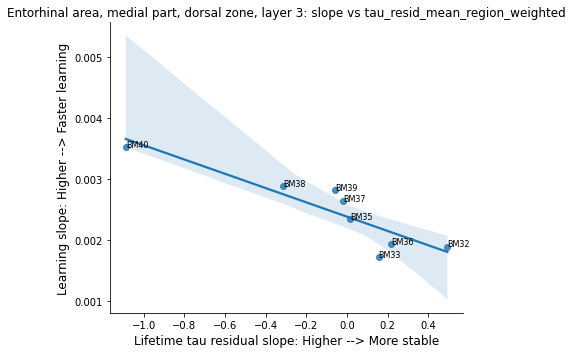

In [43]:
example_row = corr_tau_resid_name.sort_values('p_value').iloc[4]
f = plot_corr_example(example_row, region_tau_resid, behavior)
ax = f.gca()
ax.set_ylabel('Learning slope: Higher --> Faster learning', fontsize=12);
ax.set_xlabel('Lifetime tau residual slope: Higher --> More stable', fontsize=12);

,ANM,tau_resid_mean_region_weighted,slope
0,BM32,0.493813,0.001890
1,BM33,0.155421,0.001714
2,BM35,0.015292,0.002345
3,BM36,0.217269,0.001934
4,BM37,-0.020926,0.002629
5,BM38,-0.314065,0.002879
6,BM39,-0.058869,0.002819
7,BM40,-1.088531,0.003523


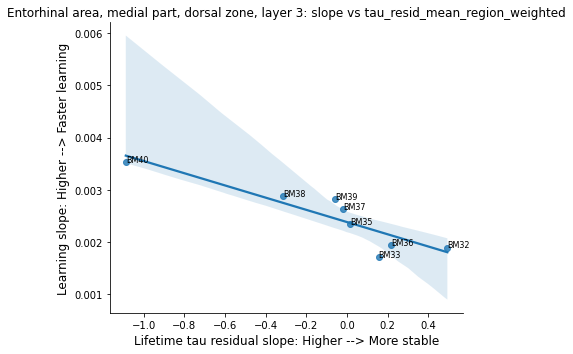

In [44]:
example_row = corr_tau_resid_name.sort_values('p_value').iloc[4]
f = plot_corr_example(example_row, region_tau_resid, behavior)
ax = f.gca()
ax.set_ylabel('Learning slope: Higher --> Faster learning', fontsize=12);
ax.set_xlabel('Lifetime tau residual slope: Higher --> More stable', fontsize=12);

,ANM,tau_resid_mean_region_weighted,time_to_criterion_trial
0,BM32,-0.068519,606.0
1,BM33,0.149222,886.0
2,BM35,-0.282751,501.0
3,BM36,0.215463,1209.0
4,BM37,0.192692,1045.0
5,BM38,-0.110272,498.0
6,BM39,0.157737,165.0
7,BM40,0.500428,179.0


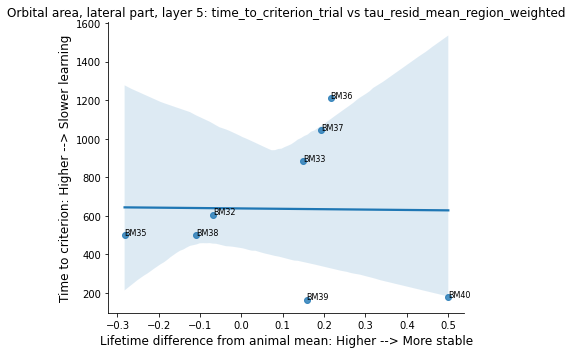

In [45]:
# find row by name from corr_tau_resid_name
example_row = corr_tau_resid_name[corr_tau_resid_name['region'] == 'Orbital area, lateral part, layer 5'].iloc[4]

f = plot_corr_example(example_row, region_tau_resid, behavior)
ax = f.gca()
ax.set_ylabel('Time to criterion: Higher --> Slower learning', fontsize=12);
ax.set_xlabel('Lifetime difference from animal mean: Higher --> More stable', fontsize=12);

,ANM,tau_resid_mean_region_weighted,time_to_criterion_trial
0,BM32,-0.366935,606.0
1,BM33,-0.552949,886.0
2,BM35,-0.591063,501.0
3,BM36,0.111157,1209.0
4,BM37,-0.286650,1045.0
5,BM38,-0.620689,498.0
6,BM39,-0.769582,165.0
7,BM40,-0.340893,179.0


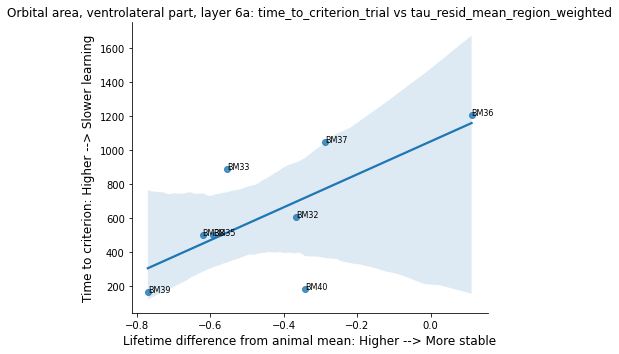

In [80]:
# find row by name from corr_tau_resid_name
example_row = corr_tau_resid_name[corr_tau_resid_name['region'] == 'Orbital area, ventrolateral part, layer 6a'].iloc[4]

f = plot_corr_example(example_row, region_tau_resid, behavior)
ax = f.gca()
ax.set_ylabel('Time to criterion: Higher --> Slower learning', fontsize=12);
ax.set_xlabel('Lifetime difference from animal mean: Higher --> More stable', fontsize=12);

In [48]:
corr_tau_resid_name.sort_values('p_value').head(10)

,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse
128,slope,"Entorhinal area, medial part, dorsal zone, lay...",8,-0.032952,0.002948,-0.962916,0.000124,Name,fraction,True,fraction_resid,1991895.0,3.906651,Hippocampal formation
1546,mean_accuracy,"Primary motor area, Layer 6a",8,8.338113,0.741327,0.914619,0.001458,Name,fraction,True,fraction_resid,4376775.0,2.836213,Isocortex
2123,mean_dprime,"Primary motor area, Layer 6a",8,59.944275,1.707713,0.909250,0.001744,Name,fraction,True,fraction_resid,4376775.0,2.758558,Isocortex
969,intercept,"Primary motor area, Layer 6a",8,77.938218,0.503313,0.904726,0.002011,Name,fraction,True,fraction_resid,4376775.0,2.696696,Isocortex
129,slope,"Entorhinal area, medial part, dorsal zone, lay...",8,-0.021346,0.002575,-0.902329,0.002162,Name,fraction,True,fraction_resid,1337784.0,2.665129,Hippocampal formation
354,slope,"Posterior auditory area, layer 6b",8,-0.022811,0.002038,-0.890787,0.002996,Name,fraction,True,fraction_resid,24769.0,2.523506,Isocortex
533,slope,"Temporal association areas, layer 6b",8,-0.029770,0.001788,-0.886667,0.003337,Name,fraction,True,fraction_resid,128755.0,2.476661,Isocortex
335,slope,"Perirhinal area, layer 6b",8,-0.027845,0.001715,-0.885821,0.003410,Name,fraction,True,fraction_resid,23179.0,2.467249,Isocortex
89,slope,Cuneate nucleus,4,0.015910,0.003638,0.994161,0.005839,Name,fraction,True,fraction_resid,114706.0,2.233673,Medulla
374,slope,"Postrhinal area, layer 6b",8,-0.028923,0.001487,-0.856799,0.006576,Name,fraction,True,fraction_resid,51271.0,2.182069,Isocortex


In [79]:
# Choose region of interest
roi = example_row.region  # e.g., "Hippocampus field CA1"

# Per-animal mean tau (all regions)
tau_mean_per_animal = combined_filtered.groupby("ANM")["tau"].mean().rename("tau_mean_animal")

# Rows for this region
region_rows = combined_filtered[combined_filtered["Name"] == roi].copy()
region_rows = region_rows.merge(tau_mean_per_animal, on="ANM", how="left")
region_rows["tau_resid"] = region_rows["tau"] - region_rows["tau_mean_animal"]

# Show raw and residual tau values
display(region_rows[["ANM", "Name", "tau", "tau_mean_animal", "tau_resid", "N"]].head(30))

# Weighted per-animal summaries for this region
def weighted_mean(arr, weights):
    import numpy as np
    m = np.isfinite(arr) & np.isfinite(weights) & (weights > 0)
    return (arr[m] * weights[m]).sum() / weights[m].sum() if m.any() else float("nan")

summaries = []
for ani, sub in region_rows.groupby("ANM"):
    w = sub["N"].to_numpy()
    summaries.append({
        "ANM": ani,
        "tau_mean_weighted": weighted_mean(sub["tau"].to_numpy(), w),
        "tau_resid_weighted": weighted_mean(sub["tau_resid"].to_numpy(), w),
        "N_sum": sub["N"].sum(),
    })
import pandas as pd
summary_df = pd.DataFrame(summaries)
# After building summary_df as above
beh_cols = ["ANM", "slope", "intercept", "mean_accuracy", "mean_dprime",
            "time_to_criterion_trial", "within_day_gain_sum"]
summary_with_beh = summary_df.merge(behavior[beh_cols], on="ANM", how="left")
display(summary_with_beh)



,ANM,Name,tau,tau_mean_animal,tau_resid,N
0,BM32,"Orbital area, lateral part, layer 6a",3.736290,4.188321,-0.452032,26319.0
1,BM32,"Orbital area, lateral part, layer 6a",4.236072,4.188321,0.047750,35904.0
2,BM33,"Orbital area, lateral part, layer 6a",6.866604,6.376184,0.490420,1960.0
3,BM33,"Orbital area, lateral part, layer 6a",5.825308,6.376184,-0.550876,46951.0
4,BM33,"Orbital area, lateral part, layer 6a",5.512381,6.376184,-0.863803,45833.0
5,BM34,"Orbital area, lateral part, layer 6a",6.099478,6.556460,-0.456982,46348.0
6,BM34,"Orbital area, lateral part, layer 6a",5.701227,6.556460,-0.855234,46514.0
7,BM37,"Orbital area, lateral part, layer 6a",6.701760,6.216883,0.484877,17624.0
8,BM37,"Orbital area, lateral part, layer 6a",5.804850,6.216883,-0.412033,33708.0
9,BM37,"Orbital area, lateral part, layer 6a",5.232417,6.216883,-0.984466,19746.0


,ANM,tau_mean_weighted,tau_resid_weighted,N_sum,slope,intercept,mean_accuracy,mean_dprime,time_to_criterion_trial,within_day_gain_sum
0,BM32,4.024675,-0.163647,62223.0,0.001890,0.019690,0.662316,1.118724,606.0,9.045877
1,BM33,5.695469,-0.680715,94744.0,0.001714,-0.739395,0.547481,0.326817,886.0,8.478892
2,BM34,5.899996,-0.656464,92862.0,NaN,NaN,NaN,NaN,NaN,NaN
3,BM35,5.505120,-0.537805,67790.0,0.002345,-0.213941,0.671221,1.144012,501.0,8.738465
4,BM36,5.651175,-0.072194,50827.0,0.001934,-1.434306,0.594896,0.659529,1209.0,9.849362
5,BM37,5.868216,-0.348668,71078.0,0.002629,-1.423463,0.524561,0.181751,1045.0,8.977398
6,BM38,6.263179,-0.647148,62040.0,0.002879,-0.466209,0.674256,1.199128,498.0,11.826728
7,BM39,7.179449,-0.807729,62332.0,0.002819,1.786640,0.853448,2.640059,165.0,11.843940
8,BM40,6.997347,-0.284983,56581.0,0.003523,1.488121,0.866513,2.538851,179.0,7.477000


WED

Precomputing per-animal global tau pools...


  0%|          | 0/7 [00:00<?, ?it/s]

{'BM32': 3.6307430890958776,
 'BM33': 5.210674893885986,
 'BM34': 5.372494075695852,
 'BM35': 5.019091919204382,
 'BM36': 4.8337884728093705,
 'BM37': 5.137103470410019,
 'BM38': 5.721067544303515}

In [60]:
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import ast
from scipy.stats import linregress
import multiprocessing as mp


np.random.seed(0)
region_col = "Name"
n_boot =   3000          # adjust for speed/precision
sample_size = 20_000  # draws per animal-region AND per animal-global
min_animals = 6
min_region_pixels = 100_000
n_jobs = np.floor(mp.cpu_count()/2).astype(int)  # or set to a number to limit cores

def to_array(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.asarray(val, float).ravel()
    if isinstance(val, str):
        try:
            return np.asarray(ast.literal_eval(val), float).ravel()
        except Exception:
            return np.array([], float)
    return np.array([], float)

# Precompute per-animal all-region tau pools
animal_all_tau = {}
print("Precomputing per-animal global tau pools...")
for ani, sub in tqdm(combined_filtered.groupby("ANM"), leave=False):
    vals = np.concatenate([to_array(v) for v in sub["tau_values"] if to_array(v).size])
    if vals.size:
        animal_all_tau[ani] = vals

# Precompute per animal-region arrays
region_animal_arrays = {}
print("Precomputing per-animal-region tau pools...")
for (reg, ani), sub in tqdm(combined_filtered.groupby([region_col, "ANM"]), leave=False):
    vals = np.concatenate([to_array(v) for v in sub["tau_values"] if to_array(v).size])
    if vals.size and ani in animal_all_tau:
        region_animal_arrays.setdefault(reg, {})[ani] = vals

# Filter regions by pixel count
region_pixels = combined_filtered.groupby(region_col)["N"].sum().to_dict()
filtered_items = [
    (reg, animal_map)
    for reg, animal_map in region_animal_arrays.items()
    if region_pixels.get(reg, 0) >= min_region_pixels
]
print(f"Keeping {len(filtered_items)} regions (>= {min_region_pixels} pixels) out of {len(region_animal_arrays)}")

def bootstrap_region(args):
    reg, animal_map = args
    records = []
    boot_means = []
    for ani, vals in animal_map.items():
        glob = animal_all_tau.get(ani)
        if vals.size == 0 or glob is None or glob.size == 0:
            continue
        # vectorized bootstrap for this animal
        reg_idx = np.random.randint(0, vals.size, size=(n_boot, sample_size))
        glob_idx = np.random.randint(0, glob.size, size=(n_boot, sample_size))
        reg_means = vals[reg_idx].mean(axis=1)
        glob_means = glob[glob_idx].mean(axis=1)
        centered = reg_means - glob_means
        boot_means.append(pd.DataFrame({
            "boot": np.arange(n_boot),
            "ANM": ani,
            "tau_boot_mean_centered": centered,
        }))
    if not boot_means:
        return pd.DataFrame()
    boot_df = pd.concat(boot_means, ignore_index=True)
    for metric in metrics_to_use:
        beh_sub = behavior[["ANM", metric]].dropna()
        merged = boot_df.merge(beh_sub, on="ANM")
        if merged.empty:
            continue
        for b, sub_b in merged.groupby("boot"):
            if sub_b["ANM"].nunique() < min_animals:
                continue
            lr = linregress(sub_b["tau_boot_mean_centered"], sub_b[metric])
            records.append({
                "boot": b,
                "region": reg,
                "metric": metric,
                "slope": lr.slope,
                "p_value": lr.pvalue,
                "n_animals": sub_b["ANM"].nunique(),
            })
    return pd.DataFrame(records)

print("Running parallel bootstraps...")
with mp.Pool(n_jobs) as pool:
    results = list(tqdm(pool.imap(bootstrap_region, filtered_items),
                        total=len(filtered_items), desc="Regions"))

boot_corr = pd.concat([r for r in results if not r.empty], ignore_index=True)

summary_list = []
for (reg, metric), sub in boot_corr.groupby(['region','metric']):
    slopes = sub['slope']
    summary_list.append({
        'region': reg,
        'metric': metric,
        'slope_mean': slopes.mean(),
        'slope_std': slopes.std(ddof=1),
        'sign_frac_pos': (slopes > 0).mean(),
        'frac_sig_p05': (sub['p_value'] < 0.05).mean(),
        'n_boot': len(sub),
        'n_animals_min': sub['n_animals'].min(),
        'region_N_sum': region_pixels.get(reg, np.nan),
    })
boot_summary = pd.DataFrame(summary_list)


Precomputing per-animal global tau pools...


  0%|          | 0/9 [00:00<?, ?it/s]

Precomputing per-animal-region tau pools...


  0%|          | 0/4977 [00:00<?, ?it/s]

Keeping 458 regions (>= 100000 pixels) out of 581
Running parallel bootstraps...


Regions:   0%|          | 0/458 [00:00<?, ?it/s]

In [52]:
import multiprocessing as mp
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import ast
from scipy.stats import linregress

np.random.seed(0)
region_col = "Name"
n_boot = 3000
sample_size = 30_000
batch = 100
min_animals = 5
metrics_to_use = metrics  # or set explicitly
n_jobs = mp.cpu_count()-4

def to_array(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.asarray(val, float).ravel()
    if isinstance(val, str):
        try:
            return np.asarray(ast.literal_eval(val), float).ravel()
        except Exception:
            return np.array([], float)
    return np.array([], float)

# 1) Precompute global tau mean per animal
animal_global_mean = {}
for ani, sub in combined_filtered.groupby("ANM"):
    vals = np.concatenate([to_array(v) for v in sub["tau_values"] if to_array(v).size])
    if vals.size:
        animal_global_mean[ani] = np.median(vals)
missing_animals = set(combined_filtered["ANM"].unique()) - set(animal_global_mean)
if missing_animals:
    raise ValueError(f"Missing global tau mean for animals: {sorted(missing_animals)}")

# 2) Per animal–region pools
region_animal_arrays = {}
for (reg, ani), sub in combined_filtered.groupby([region_col, "ANM"]):
    vals = np.concatenate([to_array(v) for v in sub["tau_values"] if to_array(v).size])
    if vals.size:
        region_animal_arrays.setdefault(reg, {})[ani] = vals

def bootstrap_region(args):
    reg, animal_map = args
    rows = []
    for ani, vals in animal_map.items():
        gmean = animal_global_mean[ani]  # will KeyError if missing
        n_eff = min(sample_size, vals.size)
        for start in range(0, n_boot, batch):
            k = min(batch, n_boot - start)
            idx = np.random.randint(0, vals.size, size=(k, n_eff))
            reg_means = vals[idx].mean(axis=1)
            centered = reg_means - gmean
            rows.append(pd.DataFrame({
                "boot": np.arange(start, start + k),
                "ANM": ani,
                "tau_boot_mean_centered": centered,
            }))
    boot_df = pd.concat(rows, ignore_index=True)
    records = []
    for metric in metrics_to_use:
        beh_sub = behavior[["ANM", metric]].dropna()
        merged = boot_df.merge(beh_sub, on="ANM")
        for b, sub_b in merged.groupby("boot"):
            if sub_b["ANM"].nunique() < min_animals:
                continue
            lr = linregress(sub_b["tau_boot_mean_centered"], sub_b[metric])
            records.append({
                "boot": b,
                "region": reg,
                "metric": metric,
                "slope": lr.slope,
                "p_value": lr.pvalue,
                "n_animals": sub_b["ANM"].nunique(),
            })
    return pd.DataFrame(records)

with mp.Pool(n_jobs) as pool:
    results = list(tqdm(pool.imap(bootstrap_region, region_animal_arrays.items()),
                        total=len(region_animal_arrays), desc="Regions"))
boot_corr = pd.concat(results, ignore_index=True)


Regions:   0%|          | 0/581 [00:00<?, ?it/s]

In [78]:
animal_global_mean


{'BM32': 3.632351875305176,
 'BM33': 4.979085445404053,
 'BM34': 5.10575532913208,
 'BM35': 4.835780620574951,
 'BM36': 4.5970988273620605,
 'BM37': 4.920000076293945,
 'BM38': 5.4297776222229,
 'BM39': 6.287804126739502,
 'BM40': 5.849908351898193}

In [61]:
from datetime import datetime
out_dir = Path("/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning")
out_dir.mkdir(parents=True, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

boot_corr_path = out_dir / f"boot_corr_tau_resid_{ts}.csv"
boot_summary_path = out_dir / f"boot_summary_tau_resid_{ts}.csv"

boot_corr.to_csv(boot_corr_path, index=False)
boot_summary.to_csv(boot_summary_path, index=False)

print(f"Saved boot_corr to {boot_corr_path}")
print(f"Saved boot_summary to {boot_summary_path}")

Saved boot_corr to /groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/boot_corr_tau_resid_20260707_103351.csv
Saved boot_summary to /groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/boot_summary_tau_resid_20260707_103351.csv


In [62]:
from pathlib import Path
import pandas as pd

out_dir = Path("/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning")
corr_files = sorted(out_dir.glob("boot_corr_tau_resid_*.csv"))
summary_files = sorted(out_dir.glob("boot_summary_tau_resid_*.csv"))
if not corr_files or not summary_files:
    raise FileNotFoundError("No saved boot_corr/boot_summary files found.")

boot_corr = pd.read_csv(corr_files[-1])
boot_summary = pd.read_csv(summary_files[-1])

print(f"Loaded {corr_files[-1]}")
print(f"Loaded {summary_files[-1]}")
boot_summary.head()


Loaded /groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/boot_corr_tau_resid_20260707_103351.csv
Loaded /groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/boot_summary_tau_resid_20260707_103351.csv


,region,metric,slope_mean,slope_std,sign_frac_pos,frac_sig_p05,n_boot,n_animals_min,region_N_sum
0,"Accessory olfactory bulb, glomerular layer",intercept,-1.171529,0.010250,0.0,0.922333,3000,8,132594.0
1,"Accessory olfactory bulb, glomerular layer",mean_accuracy,-0.145943,0.001064,0.0,1.000000,3000,8,132594.0
2,"Accessory olfactory bulb, glomerular layer",mean_dprime,-1.022343,0.007746,0.0,1.000000,3000,8,132594.0
3,"Accessory olfactory bulb, glomerular layer",slope,-0.000396,0.000005,0.0,0.000000,3000,8,132594.0
4,"Accessory olfactory bulb, glomerular layer",time_to_criterion_trial,353.177105,3.210254,1.0,0.000000,3000,8,132594.0


In [63]:

# Rank per metric: high mean slope and consistent sign
ranked = {}
metrics_to_use = [
    "slope",
    "intercept",
    "mean_accuracy",
    "mean_dprime",
    "time_to_criterion_trial",
    "within_day_gain_sum",
]
# Map region -> original pixel count (sum of N across that region)
region_pixels = combined_filtered.groupby("Name")["N"].sum().to_dict()

# Add to boot_summary
# Add absolute slope stats
boot_summary["slope_abs_mean"] = boot_summary["slope_mean"].abs()
boot_summary["slope_abs_std"] = boot_summary["slope_std"]  # std of signed slopes; add another pass if you need std of abs
# Include region size if not already
region_pixels = combined_filtered.groupby("Name")["N"].sum().to_dict()
boot_summary["region_N_sum"] = boot_summary["region"].map(region_pixels)

# Rebuild ranked dict using absolute slope
ranked = {}
for metric in metrics_to_use:
    dfm = boot_summary[
        (boot_summary["metric"] == metric) &
        (boot_summary["n_animals_min"] >= min_animals) &
        (boot_summary["frac_sig_p05"] > 0.8)
    ].copy()
    dfm = dfm.sort_values("slope_mean", ascending=False)  # or slope_abs_mean if you prefer
    ranked[metric] = dfm.head(100)

for metric, dfm in ranked.items():
    print(f"\nTop regions for metric: {metric} (frac_sig_p05 > 0.8)\n")
    display(dfm[[
        "region", "slope_mean", "slope_std", "sign_frac_pos",
        "frac_sig_p05", "n_boot", "n_animals_min", "region_N_sum"
    ]])



Top regions for metric: slope (frac_sig_p05 > 0.8)



,region,slope_mean,slope_std,sign_frac_pos,frac_sig_p05,n_boot,n_animals_min,region_N_sum
2211,"Secondary motor area, layer 6a",0.008425,0.000638,1.0,0.994667,3000,8,3358095.0
1773,"Primary motor area, Layer 6a",0.004207,0.000185,1.0,1.000000,3000,8,4376775.0
2001,"Primary somatosensory area, upper limb, layer 6a",0.003253,0.000115,1.0,1.000000,3000,8,1520741.0
1965,"Primary somatosensory area, unassigned, layer 5",0.001420,0.000014,1.0,1.000000,3000,8,413508.0
1839,"Primary somatosensory area, lower limb, layer 5",0.001377,0.000018,1.0,1.000000,3000,8,938624.0
1959,"Primary somatosensory area, unassigned, layer 4",0.001377,0.000018,1.0,1.000000,3000,8,260943.0
1905,"Primary somatosensory area, nose, layer 5",0.001374,0.000020,1.0,0.999667,3000,8,890104.0
1995,"Primary somatosensory area, upper limb, layer 5",0.001212,0.000012,1.0,1.000000,3000,8,1281839.0
141,"Anterior cingulate area, dorsal part, layer 5",0.001168,0.000016,1.0,0.999667,3000,8,1745930.0
165,"Anterior cingulate area, ventral part, layer 2/3",0.001135,0.000015,1.0,1.000000,3000,8,780227.0



Top regions for metric: intercept (frac_sig_p05 > 0.8)



,region,slope_mean,slope_std,sign_frac_pos,frac_sig_p05,n_boot,n_animals_min,region_N_sum
1770,"Primary motor area, Layer 6a",9.140575,0.370211,1.0,1.000000,3000,8,4376775.0
282,Area prostriata,3.877971,0.064062,1.0,1.000000,3000,8,453123.0
168,"Anterior cingulate area, ventral part, layer 5",3.655555,0.066692,1.0,1.000000,3000,8,1571608.0
696,"Frontal pole, layer 2/3",1.483508,0.010448,1.0,1.000000,3000,7,323358.0
0,"Accessory olfactory bulb, glomerular layer",-1.171529,0.010250,0.0,0.922333,3000,8,132594.0
774,Hippocampo-amygdalar transition area,-2.369544,0.036681,0.0,0.996333,3000,8,696536.0
708,"Frontal pole, layer 6a",-2.645955,0.029004,0.0,1.000000,3000,8,127675.0
222,"Anterolateral visual area, layer 6a",-3.013801,0.055573,0.0,1.000000,3000,7,132232.0
618,"Entorhinal area, medial part, dorsal zone, lay...",-3.048062,0.058626,0.0,1.000000,3000,8,1991895.0
564,Ectorhinal area/Layer 6a,-3.070521,0.057436,0.0,1.000000,3000,8,585436.0



Top regions for metric: mean_accuracy (frac_sig_p05 > 0.8)



...

,region,slope_mean,slope_std,sign_frac_pos,frac_sig_p05,n_boot,n_animals_min,region_N_sum
1772,"Primary motor area, Layer 6a",6.888445,0.278742,1.0,1.000000,3000,8,4376775.0
170,"Anterior cingulate area, ventral part, layer 5",2.800296,0.050016,1.0,1.000000,3000,8,1571608.0
2,"Accessory olfactory bulb, glomerular layer",-1.022343,0.007746,0.0,1.000000,3000,8,132594.0
260,"Anteromedial visual area, layer 6a",-1.647591,0.022305,0.0,1.000000,3000,8,203346.0
776,Hippocampo-amygdalar transition area,-1.926345,0.028481,0.0,1.000000,3000,8,696536.0
2042,"Primary visual area, layer 6b",-2.009683,0.024491,0.0,1.000000,3000,8,262055.0
710,"Frontal pole, layer 6a",-2.025481,0.019280,0.0,1.000000,3000,8,127675.0
566,Ectorhinal area/Layer 6a,-2.445928,0.043942,0.0,1.000000,3000,8,585436.0
224,"Anterolateral visual area, layer 6a",-2.471381,0.043301,0.0,1.000000,3000,7,132232.0
488,"Dorsal auditory area, layer 6a",-2.545764,0.044664,0.0,1.000000,3000,8,269564.0



Top regions for metric: time_to_criterion_trial (frac_sig_p05 > 0.8)



,region,slope_mean,slope_std,sign_frac_pos,frac_sig_p05,n_boot,n_animals_min,region_N_sum
1324,"Orbital area, medial part, layer 6a",1625.050596,42.735643,1.0,1.000000,3000,8,280956.0
982,"Lateral visual area, layer 6a",1559.910347,48.789083,1.0,0.919667,3000,8,340582.0
1348,"Orbital area, ventrolateral part, layer 6a",1377.192546,26.256995,1.0,1.000000,3000,8,325421.0
1300,"Orbital area, lateral part, layer 6a",1338.924227,37.857787,1.0,0.953000,3000,8,620477.0
610,"Entorhinal area, lateral part, layer 6a",1285.218802,28.417234,1.0,1.000000,3000,8,1672952.0
1576,"Posterior auditory area, layer 6a",1212.771455,26.440770,1.0,1.000000,3000,8,113750.0
1678,"Postrhinal area, layer 6a",1147.464193,25.008680,1.0,1.000000,3000,8,289384.0
568,Ectorhinal area/Layer 6a,931.345283,17.587430,1.0,0.964333,3000,8,585436.0
712,"Frontal pole, layer 6a",850.602176,9.005252,1.0,1.000000,3000,8,127675.0
778,Hippocampo-amygdalar transition area,824.055301,11.860656,1.0,1.000000,3000,8,696536.0



Top regions for metric: within_day_gain_sum (frac_sig_p05 > 0.8)



,region,slope_mean,slope_std,sign_frac_pos,frac_sig_p05,n_boot,n_animals_min,region_N_sum
413,Crus 1,-4.248537,0.085145,0.0,1.0,3000,8,4077878.0
1415,Parasubiculum,-4.296736,0.083413,0.0,1.0,3000,8,1411203.0
719,Fundus of striatum,-5.286587,0.109590,0.0,1.0,3000,8,663260.0


In [ ]:
# find row by name from corr_tau_resid_name
example_row = corr_tau_resid_name[corr_tau_resid_name['region'] == 'Orbital area, ventrolateral part, layer 6a'].iloc[4]

f = plot_corr_example(example_row, region_tau_resid, behavior)
ax = f.gca()
ax.set_ylabel('Time to criterion: Higher --> Slower learning', fontsize=12);
ax.set_xlabel('Lifetime difference from animal mean: Higher --> More stable', fontsize=12);

In [ ]:
animal_all_tau = {}
print("Precomputing per-animal glaobal tau pools...")
for ani, sub in tqdm(combined_filtered.groupby("ANM"), leave=False):
    vals = np.concatenate([to_array(v) for v in sub["tau_values"] if to_array(v).size])
    if vals.size:
        animal_all_tau[ani] = avals
animal_global_mean = {ani: np.median(vals) for ani, vals in animal_all_tau.items()}


Precomputing per-animal global tau pools...


  0%|          | 0/9 [00:00<?, ?it/s]

In [65]:
animal_global_mean


{'BM32': 3.632351875305176,
 'BM33': 4.979085445404053,
 'BM34': 5.10575532913208,
 'BM35': 4.835780620574951,
 'BM36': 4.5970988273620605,
 'BM37': 4.920000076293945,
 'BM38': 5.4297776222229,
 'BM39': 6.287804126739502,
 'BM40': 5.849908351898193}

In [77]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import tifffile as tiff

out_dir = Path("../outputs/fraction_pulse_whole_slide")
out_dir.mkdir(parents=True, exist_ok=True)

# Target ROI name
TARGET_NAME = "Primary motor area, Layer 6a"
roi = TARGET_NAME
roi_df = combined_filtered[combined_filtered["Name"] == roi].copy()

# Round → base path
base_map = {
    12: Path("/nearline/spruston/Boaz/DELTA/GluA2_Round12"),
    13: Path("/nearline/spruston/Boaz/DELTA/GluA2_Round13"),
}

# Preload label table
label_df = pd.read_csv(
    Path("../labels.txt"),
    sep=r"\s+",
    comment="#",
    header=None,
    names=["ID", "R", "G", "B", "A", "VIS", "MSH", "LABEL"],
)
label_df["LABEL"] = label_df["LABEL"].str.strip('"')
label_df["hex"] = label_df.apply(lambda r: f"{int(r.R):02X}{int(r.G):02X}{int(r.B):02X}", axis=1)
hex_to_id   = dict(zip(label_df["hex"], label_df["ID"]))

def decode_nl_png(nl_path: Path):
    png = np.array(Image.open(nl_path).convert("RGB"), dtype=np.uint8)
    h, w, _ = png.shape
    flat = png.reshape(-1, 3)
    hex_vals = np.array([f"{r:02X}{g:02X}{b:02X}" for r, g, b in flat])
    ids = np.array([hex_to_id.get(hx, 0) for hx in hex_vals], dtype=np.int64).reshape(h, w)
    return ids

target_ids = label_df.loc[label_df["LABEL"].str.lower() == TARGET_NAME.lower(), "ID"].unique()
if len(target_ids) == 0:
    raise ValueError(f"Region name not found: {TARGET_NAME}")

saved = []
missing = []
for _ , row in tqdm(roi_df.iterrows(), total=len(roi_df)):
    rnd = int(row.get("Round", 0))
    base_dir = base_map.get(rnd)
    if base_dir is None:
        missing.append((row["ANM"], "no base_dir", row.get("File", "")))
        continue
    cy5_path, cy3_path = derive_cy_paths(base_dir, Path(row["File"]).name)
    if not cy5_path.exists() or not cy3_path.exists():
        missing.append((row["ANM"], cy5_path, cy3_path))
        continue
    mean = animal_global_mean[row["ANM"]]
    with tiff.TiffFile(cy5_path) as tf:
        arr = tf.series[0].asarray()
    pulse = arr[2, :, :] if arr.ndim == 3 else arr

    with tiff.TiffFile(cy3_path) as tf:
        arr = tf.series[0].asarray()
    chase = arr[1, :, :] if arr.ndim == 3 else arr

    denom = pulse + chase
    frac = np.divide(pulse, denom, out=np.zeros_like(pulse, dtype=np.float32), where=denom != 0)
    frac = np.clip(frac, 0, 1)
    tau = -4./np.log(frac + 1e-6)  # avoid log(0)
    # out_path = out_dir / f"{row['ANM']}_{cy5_path.stem.replace('_CY5','')}_tau.tif"
    # tiff.imwrite(out_path, tau, imagej=True)
    # saved.append(out_path)

    # Decode atlas PNG and build mask
    nl_path = base_dir / (Path(row["File"]).stem.replace("_CY5", "") + "_nl.png")
    if nl_path.exists():
        ids = decode_nl_png(nl_path)
        mask = np.isin(ids, target_ids)
        # save overlay for quick viewing
        plt.figure(figsize=(8, 8))
        plt.imshow(tau, cmap="viridis", vmin=2, vmax=10)
        plt.colorbar()
        mask_img = Image.fromarray(mask.astype(np.uint8)*255)
        mask_resized = np.array(mask_img.resize((frac.shape[1], frac.shape[0]), resample=Image.NEAREST)) > 0
        plt.contour(mask_resized, colors="red", linewidths=1)
        plt.axis("off")
        plt.title(f"{row['ANM']} {TARGET_NAME}")
        overlay_path = out_dir / f"{row['ANM']}_{cy5_path.stem.replace('_CY5','')}_overlay.png"
        
        plt.tight_layout()
        plt.savefig(overlay_path, dpi=200)
        plt.close()

print(f"Saved {len(saved)} fraction images to {out_dir}")
if missing:
    print("Missing pairs (ANM, CY5, CY3):")
    for m in missing[:10]:
        print(m)


  0%|          | 0/54 [00:00<?, ?it/s]

AttributeError: type object 'Image' has no attribute 'open'

In [74]:
import math
import matplotlib.pyplot as plt

# Collect per-animal panels
panels = []
missing = []

for _, row in tqdm(roi_df.iterrows(), total=len(roi_df)):
    ani = row["ANM"]
    rnd = int(row.get("Round", 0))
    base_dir = base_map.get(rnd)
    if base_dir is None:
        missing.append((ani, "no base_dir", row.get("File", "")))
        continue

    cy5_path, cy3_path = derive_cy_paths(base_dir, Path(row["File"]).name)
    if not cy5_path.exists() or not cy3_path.exists():
        missing.append((ani, cy5_path, cy3_path))
        continue

    with tiff.TiffFile(cy5_path) as tf:
        arr = tf.series[0].asarray()
    pulse = arr[2, :, :] if arr.ndim == 3 else arr

    with tiff.TiffFile(cy3_path) as tf:
        arr = tf.series[0].asarray()
    chase = arr[1, :, :] if arr.ndim == 3 else arr

    denom = pulse + chase
    frac = np.divide(pulse, denom, out=np.zeros_like(pulse, dtype=np.float32), where=denom != 0)
    frac = np.clip(frac, 0, 1)
    tau = -4.0 / np.log(frac + 1e-6)  # days
    tau = tau - animal_global_mean.get(ani)
    print(f"Animal {ani}: global mean tau = {animal_global_mean.get(ani):.3f} days")
    nl_path = base_dir / (Path(row["File"]).stem.replace("_CY5", "") + "_nl.png")
    if not nl_path.exists():
        missing.append((ani, "missing nl", nl_path))
        continue

    ids = decode_nl_png(nl_path)
    mask = np.isin(ids, target_ids)
    mask_resized = np.array(
        Image.fromarray(mask.astype(np.uint8) * 255)
        .resize((frac.shape[1], frac.shape[0]), resample=Image.NEAREST)
    ) > 0

    panels.append((ani, tau, mask_resized))



  0%|          | 0/29 [00:00<?, ?it/s]

Animal BM32: global mean tau = 3.632 days


NameError: name 'Image' is not defined

In [70]:
# Plot subplots
n = len(panels)
if n:
    cols = min(3, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (ani, tau_img, mask_img) in zip(axes, panels):
        im = ax.imshow(tau_img, cmap="viridis", vmin=-1, vmax=3)
        ax.contour(mask_img, colors="red", linewidths=1)
        ax.set_title(f"{ani} {TARGET_NAME}")
        ax.axis("off")
    for ax in axes[len(panels):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

if missing:
    print("Missing items (showing up to 10):")
    for m in missing[:10]:
        print(m)


NameError: name 'panels' is not defined

,ANM,tau_resid_mean_region_weighted,mean_accuracy
0,BM32,-0.380703,0.662316
1,BM33,-0.691705,0.547481
2,BM35,-0.744246,0.671221
3,BM36,-0.080402,0.594896
4,BM37,-0.530975,0.524561
5,BM38,-0.618123,0.674256
6,BM39,-0.507195,0.853448
7,BM40,-0.466793,0.866513


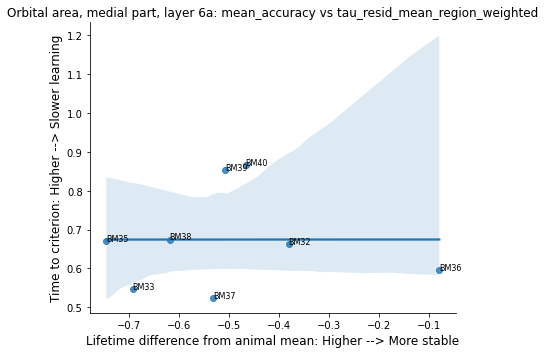

In [81]:
# find row by name from corr_tau_resid_name
example_row = corr_tau_resid_name[corr_tau_resid_name['region'] == 'Orbital area, medial part, layer 6a'].iloc[2]

f = plot_corr_example(example_row, region_tau_resid, behavior)
ax = f.gca()
ax.set_ylabel('Time to criterion: Higher --> Slower learning', fontsize=12);
ax.set_xlabel('Lifetime difference from animal mean: Higher --> More stable', fontsize=12);

In [24]:
# find row by name from corr_tau_resid_name
example_row = corr_tau_resid_name[corr_tau_resid_name['region'] == 'Entorhinal area, medial part, dorsal zone, layer 5'].iloc[2]

f = plot_corr_example(example_row, region_tau_resid, behavior)
ax = f.gca()
ax.set_ylabel('Time to criterion: Higher --> Slower learning', fontsize=12);
ax.set_xlabel('Lifetime difference from animal mean: Higher --> More stable', fontsize=12);

NameError: name 'region_tau_resid' is not defined

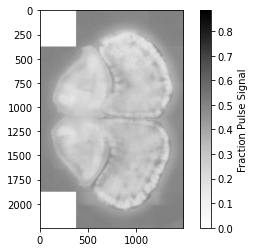

In [137]:
plt.imshow(frac, cmap='Greys')
plt.colorbar(label='Fraction Pulse Signal')

In [101]:
import os
os.listdir("/nearline/spruston/Boaz/DELTA/GluA2_Round12/")

['Slide 4 of 1_Region 005.png',
 'Slide 7 of 1_Region 002_nl.flat',
 'Slide 8 of 2_Region 001_nl.flat',
 'Slide 5 of 2_Region 006_nl.flat',
 'Slide 8 of 2_Region 004_CY3.tiff',
 'Slide 8 of 2_Region 003_DAPI.tiff',
 'Slide 8 of 2_Region 002_CY3.tiff',
 'Slide 5 of 2_Region 001_DAPI.tiff',
 'Slide 2 from cassette 1_Region 001_CY5.tiff',
 'Slide 1 from cassette 1_Region 001_Probabilities.tif',
 'Slide 1 from cassette 1_Region 001_CY3.tiff',
 'Slide 1 from cassette 1_Region 006_DAPI.tiff',
 'ds_dapi.m',
 'Slide 1 from cassette 2_Region 003_DAPI.tiff',
 'Slide 4 of 1_Region 003_DAPI.tiff',
 'Slide 5 of 1_Region 002_Probabilities.tif',
 'Slide 5 of 1_Region 004_nl.flat',
 'Slide 8 of 1_Region 001_nl.flat',
 'Slide 2 from cassette 1_Region 001_nl.png',
 'Slide 8 of 1_Region 005_nl.flat',
 'Slide 5 of 1_Region 003_nl.flat',
 'Slide 1 from cassette 2_Region 001_nl.png',
 'Slide 5 of 2_Region 002_CY3.tiff',
 'Slide 8 of 2_Region 003_nl.flat',
 'Slide 2 from cassette 2_Region 003_Probabilities.t

In [99]:
os.listdir("/nearline/spruston/Boaz")

['DELTA', 'Easi_FISH', 'Histology', 'Mesoscope']

,region,ANM,tau_raw_mean,tau_resid_mean,n_pixels_region,tau_animal_global_mean,within_day_gain_sum
0,"Laterointermediate area, layer 6a",BM32,3.621369,-0.009374,11040.0,3.630743,9.045877
1,"Laterointermediate area, layer 6a",BM33,5.225831,0.015156,23538.0,5.210675,8.478892
2,"Laterointermediate area, layer 6a",BM34,5.420564,0.048070,24263.0,5.372494,NaN
3,"Laterointermediate area, layer 6a",BM35,4.981643,-0.037449,13133.0,5.019092,8.738465
4,"Laterointermediate area, layer 6a",BM36,4.844468,0.010680,15983.0,4.833788,9.849362
5,"Laterointermediate area, layer 6a",BM37,5.022182,-0.114922,11063.0,5.137103,8.977398
6,"Laterointermediate area, layer 6a",BM38,5.576173,-0.144894,12581.0,5.721068,11.826728
7,"Laterointermediate area, layer 6a",BM39,6.557842,0.064083,8836.0,6.493759,11.843940
8,"Laterointermediate area, layer 6a",BM40,5.554547,-0.499252,16872.0,6.053799,7.477000
9,"Gustatory areas, layer 6a",BM32,3.451761,-0.178982,58726.0,3.630743,9.045877


posx and posy should be finite values
posx and posy should be finite values


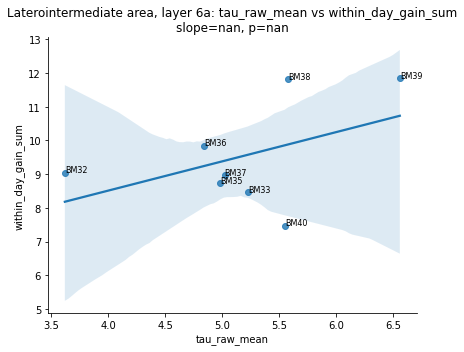

posx and posy should be finite values
posx and posy should be finite values


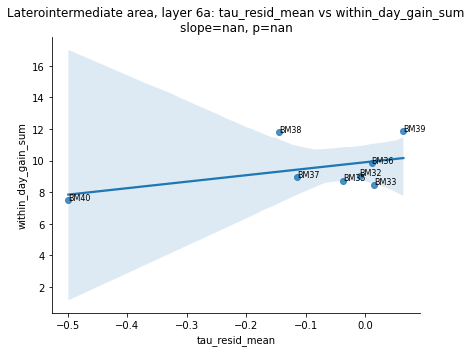

posx and posy should be finite values
posx and posy should be finite values


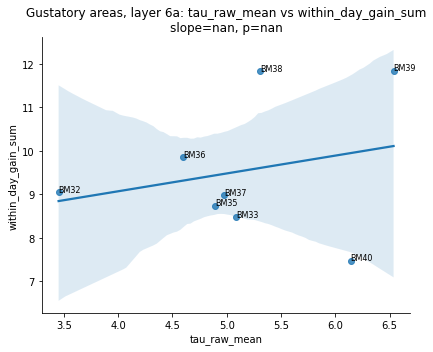

posx and posy should be finite values
posx and posy should be finite values


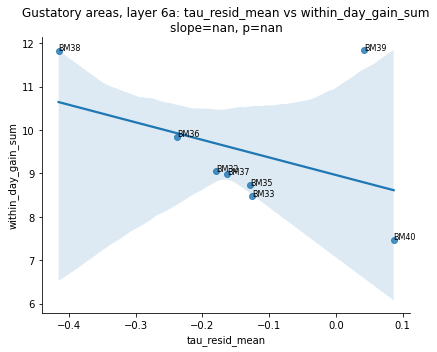

In [73]:
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

target_regions = [
    "Laterointermediate area, layer 6a",
    "Gustatory areas, layer 6a",
]

def to_array(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.asarray(val, float).ravel()
    if isinstance(val, str):
        try:
            return np.asarray(ast.literal_eval(val), float).ravel()
        except Exception:
            return np.array([], float)
    return np.array([], float)

# Global mean tau per animal (all regions)
animal_tau_mean = (
    combined_filtered.groupby("ANM")["tau_values"]
    .apply(lambda s: np.concatenate([to_array(v) for v in s if to_array(v).size]).mean()
           if any(to_array(v).size for v in s) else np.nan)
    .to_dict()
)

records = []
for reg in target_regions:
    sub = combined_filtered[combined_filtered["Name"] == reg]
    for ani, s in sub.groupby("ANM"):
        vals = np.concatenate([to_array(v) for v in s["tau_values"] if to_array(v).size])
        if vals.size == 0 or ani not in animal_tau_mean:
            continue
        raw_mean = vals.mean()
        resid_mean = raw_mean - animal_tau_mean[ani]
        n_pixels = s["N"].sum()
        records.append({
            "region": reg,
            "ANM": ani,
            "tau_raw_mean": raw_mean,
            "tau_resid_mean": resid_mean,
            "n_pixels_region": n_pixels,
            "tau_animal_global_mean": animal_tau_mean[ani],
        })

df = pd.DataFrame(records)
df = df.merge(behavior[["ANM", "within_day_gain_sum"]], on="ANM", how="left")
display(df)

# Plot raw vs behavior and residual vs behavior
for reg in target_regions:
    dfr = df[df["region"] == reg]
    if dfr.empty:
        print(f"No data for {reg}")
        continue
    for col in ["tau_raw_mean", "tau_resid_mean"]:
        plt.figure(figsize=(6,5))
        sns.regplot(data=dfr, x=col, y="within_day_gain_sum")
        sns.despine(top=True, right=True)
        for _, r in dfr.iterrows():
            plt.text(r[col], r["within_day_gain_sum"], r["ANM"], fontsize=8)
        lr = linregress(dfr[col], dfr["within_day_gain_sum"])
        plt.title(f"{reg}: {col} vs within_day_gain_sum\nslope={lr.slope:.3f}, p={lr.pvalue:.3g}")
        plt.tight_layout()
        plt.show()


In [72]:

def derive_cy_paths(base_dir: Path, file_name: str):
    stem = Path(file_name).stem
    base_stem = re.sub(r"_CY[0-9]+$", "", stem)  # drop any trailing _CYX
    cy5 = base_dir / f"{base_stem}_CY5.tiff"
    cy3 = base_dir / f"{base_stem}_CY3.tiff"
    # fallback to .tif if .tiff missing
    if not cy5.exists():
        cy5 = base_dir / f"{base_stem}_CY5.tiff"
    if not cy3.exists():
        cy3 = base_dir / f"{base_stem}_CY3.tiff"
    return cy5, cy3

saved, missing = [], []
for _, row in tqdm(roi_df.iterrows(), total=len(roi_df)):
    rnd = int(row.get("Round", 0))
    base_dir = base_map.get(rnd)
    if base_dir is None:
        missing.append((row["ANM"], "no base_dir", row.get("File", "")))
        continue
    cy5_path, cy3_path = derive_cy_paths(base_dir, Path(row["File"]).name)
    if not cy5_path.exists() or not cy3_path.exists():
        missing.append((row["ANM"], cy5_path, cy3_path))
        continue

    with tiff.TiffFile(cy5_path) as tf:
        arr = tf.series[0].asarray()  # or tf.pages[0].asarray()
    pulse = arr[2,:,:] if arr.ndim == 3 else arr

    with tiff.TiffFile(cy3_path) as tf:
        arr = tf.series[0].asarray()
    chase = arr[1,:,:] if arr.ndim == 3 else arr
    denom = pulse + chase
    frac = np.divide(pulse, denom, out=np.zeros_like(pulse, dtype=np.float32), where=denom != 0)
    frac = np.clip(frac, 0, 1)
    out_path = out_dir / f"{row['ANM']}_{cy5_path.stem.replace('_CY5','')}_fraction.tif"
    tiff.imwrite(out_path, frac, imagej=True)
    saved.append(out_path)

print(f"Saved {len(saved)} fraction images to {out_dir}")
if missing:
    print("Missing pairs (ANM, CY5, CY3):")
    for m in missing[:10]:
        print(m)


  0%|          | 0/29 [00:00<?, ?it/s]

Saved 23 fraction images to ../outputs/fraction_pulse_whole_slide
Missing pairs (ANM, CY5, CY3):
('BM39', 'no base_dir', 'Slide 1 of 1_Region 004.png')
('BM39', 'no base_dir', 'Slide 1 of 1_Region 005.png')
('BM39', 'no base_dir', 'Slide 1 of 1_Region 006.png')
('BM40', 'no base_dir', 'Slide 4 of 1_Region 004.png')
('BM40', 'no base_dir', 'Slide 4 of 1_Region 005.png')
('BM40', 'no base_dir', 'Slide 4 of 1_Region 006.png')
